In [3]:
from typing import TypedDict, List
from langgraph.graph import StateGraph
import random

In [4]:
class AgentState(TypedDict):
    msg : str
    nums : List[int]
    counter : int

In [5]:
def greeting_node(state : AgentState) -> AgentState:
    state['msg'] = "Good Morning Pineapple"
    print(state['msg'])
    return state

In [6]:
def random_node(state: AgentState) -> AgentState:
    num = random.randint(1, 100)

    state["nums"].append(num)
    state["counter"] += 1

    print(f"Iteration {state['counter']} -> Generated Number: {num}")

    return state
def random_function(state : AgentState) -> str:
    if state["counter"] >= 5:
        return "end_edge"
    else:
        return "loop_edge"

In [7]:
graph = StateGraph(AgentState)

graph.add_node("greeting", greeting_node)
graph.add_node("random", random_node)

graph.set_entry_point("greeting")

graph.add_edge("greeting", "random")

graph.add_conditional_edges(
    "random",
    random_function,
    {
        "loop_edge": "random",
        "end_edge": "__end__"
    }
)

app = graph.compile()

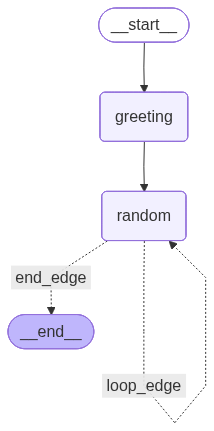

In [8]:
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
result = app.invoke(
    {
        "msg": "",
        "nums": [],
        "counter": -5 # final counter value would be 5
    }
)
print(result)

Good Morning Pineapple
Iteration -4 -> Generated Number: 56
Iteration -3 -> Generated Number: 80
Iteration -2 -> Generated Number: 64
Iteration -1 -> Generated Number: 14
Iteration 0 -> Generated Number: 81
Iteration 1 -> Generated Number: 44
Iteration 2 -> Generated Number: 65
Iteration 3 -> Generated Number: 93
Iteration 4 -> Generated Number: 58
Iteration 5 -> Generated Number: 16
{'msg': 'Good Morning Pineapple', 'nums': [56, 80, 64, 14, 81, 44, 65, 93, 58, 16], 'counter': 5}
